# Projek Akhir Data Mining
## Perbandingan K-Means, DBSCAN, Hierarchical Clustering, dan K-Medoids
### Klasterisasi Stabilitas Mata Uang ASEAN terhadap USD

**Anggota Kelompok:**
- IDR, MYR, THB, PHP, SGD, VND

Notebook ini berisi pipeline lengkap dari pengambilan data sampai clustering.

---
## 1. Import Library

In [1]:
# Import library yang dibutuhkan
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
import scipy.cluster.hierarchy as sch

# Setting grafik
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('Semua library berhasil diimport')

Semua library berhasil diimport


## 2. Data Acquisition (Pengambilan Data)

Kita ambil data dari 2 sumber:
1. **Yahoo Finance** - data kurs harian 6 mata uang ASEAN (IDR, MYR, THB, PHP, SGD, VND) terhadap USD
2. **World Bank** - data inflasi tahunan (dari file CSV)

In [2]:
# Definisi parameter
tickers = {
    'IDR': 'IDR=X',
    'MYR': 'MYR=X',
    'THB': 'THB=X',
    'PHP': 'PHP=X',
    'SGD': 'SGD=X',
    'VND': 'VND=X'
}

start_date = '2015-01-01'
end_date = '2026-01-01'

# Download data kurs dari Yahoo Finance secara individu dengan toleransi retry
print('Mengunduh data kurs dari Yahoo Finance...')
df_kurs_list = {}
for currency, ticker in tickers.items():
    print(f"Mengunduh {currency} ({ticker})...")
    for attempt in range(3):
        try:
            data = yf.download(ticker, start=start_date, end=end_date)
            if isinstance(data.columns, pd.MultiIndex):
                prices = data.xs('Close', axis=1, level=0)
            else:
                prices = data['Close'] if 'Close' in data.columns else data
            
            if isinstance(prices, pd.DataFrame):
                prices = prices.squeeze()
                
            if not prices.empty and prices.isnull().sum() < len(prices):
                df_kurs_list[currency] = prices
                print(f"Berhasil mengunduh {currency}. Shape: {prices.shape}")
                break
        except Exception as e:
            print(f"Percobaan {attempt+1} gagal untuk {currency}: {e}")
    else:
        raise RuntimeError(f"Gagal mengunduh data untuk {currency} setelah 3 percobaan.")

df_kurs = pd.DataFrame(df_kurs_list)
print(f'Data kurs berhasil diunduh. Shape: {df_kurs.shape}')
print(df_kurs.tail())


Mengunduh data kurs dari Yahoo Finance...
Mengunduh IDR (IDR=X)...


[*********************100%***********************]  1 of 1 completed

Berhasil mengunduh IDR. Shape: (2863,)
Mengunduh MYR (MYR=X)...


[*********************100%***********************]  1 of 1 completed

Berhasil mengunduh MYR. Shape: (2864,)
Mengunduh THB (THB=X)...


...

Berhasil mengunduh PHP. Shape: (2863,)
Mengunduh SGD (SGD=X)...


[*********************100%***********************]  1 of 1 completed

Berhasil mengunduh SGD. Shape: (2863,)
Mengunduh VND (VND=X)...


[*********************100%***********************]  1 of 1 completed

Berhasil mengunduh VND. Shape: (2865,)
Data kurs berhasil diunduh. Shape: (2865, 6)
                     IDR     MYR        THB        PHP      SGD      VND
Date                                                                    
2025-12-24  16735.000000  4.0615  31.110001  58.737999  1.28443  26326.0
2025-12-26  16753.099609  4.0425  31.040001  58.776001  1.28411  26277.0
2025-12-29  16741.099609  4.0460  31.045000  58.584999  1.28433  26255.0
2025-12-30  16770.000000  4.0575  31.639999  58.835999  1.28490  26245.0
2025-12-31  16709.000000  4.0450  31.450001  58.877998  1.28390  26225.0


In [3]:
import os

# Cari file CSV inflasi
csv_path = r"C:\Users\Asus\Documents\SAINS_DATA_UNS\SEMESTER_4\DATA_MINING\PROJECT\DATA\API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_250039.csv"

df_inflation_raw = pd.read_csv(csv_path, skiprows=4)

# Mapping kode negara ISO3 ke kode mata uang
iso3_mapping = {
    'IDN': 'IDR', 'MYS': 'MYR', 'THA': 'THB',
    'PHL': 'PHP', 'SGP': 'SGD', 'VNM': 'VND'
}

# Filter hanya negara ASEAN
df_inflation = df_inflation_raw[df_inflation_raw['Country Code'].isin(iso3_mapping.keys())].copy()
df_inflation['Currency'] = df_inflation['Country Code'].map(iso3_mapping)

# Ubah format dari tahun sebagai kolom ke baris (melt) - batasi hingga tahun 2024
years_cols = [str(y) for y in range(2015, 2025) if str(y) in df_inflation.columns]
df_inflation_melt = df_inflation.melt(
    id_vars=['Currency'], 
    value_vars=years_cols,
    var_name='Year', 
    value_name='Inflation'
)
df_inflation_melt['Year'] = df_inflation_melt['Year'].astype(int)

print(f'Data inflasi berhasil dibaca. Shape: {df_inflation_melt.shape}')
print(df_inflation_melt.head(10))


Data inflasi berhasil dibaca. Shape: (60, 3)
  Currency  Year  Inflation
0      IDR  2015   6.363121
1      MYR  2015   2.104390
2      PHP  2015   0.674193
3      SGD  2015  -0.521976
4      THB  2015  -0.900425
5      VND  2015   0.631201
6      IDR  2016   3.525805
7      MYR  2016   2.090567
8      PHP  2016   1.253699
9      SGD  2016  -0.529810


## 3. Preprocessing Data

Tahapan preprocessing:
1. Interpolasi inflasi tahunan ke bulanan
2. Forward fill missing value data kurs
3. Agregasi fitur bulanan
4. Normalisasi (Z-Score)

### 3.1 Interpolasi Inflasi Tahun ke Bulanan

Data inflasi dari World Bank masih tahunan. Kita interpolasi linear ke bulanan.

In [4]:
# Interpolasi inflasi tahunan ke bulanan
print('Melakukan interpolasi inflasi tahunan ke bulanan...')

monthly_infl_rows = []

for currency in df_inflation_melt['Currency'].unique():
    curr_data = df_inflation_melt[df_inflation_melt['Currency'] == currency].sort_values('Year')
    years_arr = curr_data['Year'].values
    infl_arr = curr_data['Inflation'].values

    for i, year in enumerate(years_arr):
        current_infl = infl_arr[i]
        
        if i < len(years_arr) - 1:
            next_infl = infl_arr[i + 1]
        else:
            if len(years_arr) >= 2:
                delta = infl_arr[-1] - infl_arr[-2]
                next_infl = current_infl + delta
            else:
                next_infl = current_infl

        for month in range(1, 13):
            frac = month / 13
            monthly_infl = current_infl + (next_infl - current_infl) * frac
            monthly_infl_rows.append({
                'Currency': currency,
                'Year': year,
                'Month': month,
                'Inflation': monthly_infl
            })

df_inflation_monthly = pd.DataFrame(monthly_infl_rows)
df_inflation_monthly['Year'] = df_inflation_monthly['Year'].astype(int)

# Drop NaN (tahun yang belum rilis datanya)
nan_inflasi = df_inflation_monthly['Inflation'].isna().sum()

print(f'Inflasi bulanan siap: {len(df_inflation_monthly)} baris')
print(df_inflation_monthly.head(12))

Melakukan interpolasi inflasi tahunan ke bulanan...
Inflasi bulanan siap: 720 baris
   Currency  Year  Month  Inflation
0       IDR  2015      1   6.144866
1       IDR  2015      2   5.926610
2       IDR  2015      3   5.708355
3       IDR  2015      4   5.490100
4       IDR  2015      5   5.271845
5       IDR  2015      6   5.053590
6       IDR  2015      7   4.835335
7       IDR  2015      8   4.617080
8       IDR  2015      9   4.398825
9       IDR  2015     10   4.180570
10      IDR  2015     11   3.962315
11      IDR  2015     12   3.744060


### 3.2 Forward Fill Missing Value & Agregasi Bulanan

In [5]:
# Cek missing value sebelum preprocessing
print('=== Missing Value Data Kurs Harian ===')
print(df_kurs.isnull().sum())

total_missing = df_kurs.isnull().sum().sum()
total_sel = df_kurs.shape[0] * df_kurs.shape[1]
print(f'\nTotal missing: {total_missing} dari {total_sel} sel')

# Forward fill
df_kurs_clean = df_kurs.ffill()

# Konversi index ke datetime
df_kurs_clean.index = pd.to_datetime(df_kurs_clean.index)
df_kurs_clean['Year'] = df_kurs_clean.index.year
df_kurs_clean['Month'] = df_kurs_clean.index.month

print('\nForward fill selesai')

=== Missing Value Data Kurs Harian ===
IDR    2
MYR    1
THB    2
PHP    2
SGD    2
VND    0
dtype: int64

Total missing: 9 dari 17190 sel

Forward fill selesai


In [6]:
# Agregasi fitur bulanan
print('Mengagregasi fitur bulanan...')

agregasi_list = []

for currency in tickers.keys():
    for (year, month), group in df_kurs_clean.groupby(['Year', 'Month']):
        if len(group) < 15:
            continue
            
        prices = group[currency].dropna()
        if len(prices) == 0:
            continue
            
        # Rebase ke 100 di awal bulan
        first_price = prices.iloc[0]
        prices_rebased = (prices / first_price) * 100
        
        # a. Mean
        mean_kurs = prices_rebased.mean()
        
        # b. Std
        std_kurs = prices_rebased.std()
        
        # c. Volatility (annualized)
        log_returns = np.log(prices / prices.shift(1)).dropna()
        if len(log_returns) > 1:
            volatility = log_returns.std() * np.sqrt(252)
        else:
            volatility = 0.0
        
        # d. Pct_Change
        end_price = prices.iloc[-1]
        pct_change = ((end_price - first_price) / first_price) * 100
        
        # e. Inflation (dari data yang sudah diinterpolasi)
        infl_val = np.nan
        infl_row = df_inflation_monthly[
            (df_inflation_monthly['Currency'] == currency) & 
            (df_inflation_monthly['Year'] == year) & 
            (df_inflation_monthly['Month'] == month)
        ]
        if not infl_row.empty:
            infl_val = infl_row['Inflation'].values[0]
            
        agregasi_list.append({
            'Currency': currency,
            'Year': year,
            'Month': month,
            'Mean': mean_kurs,
            'Std': std_kurs,
            'Volatility': volatility,
            'Pct_Change': pct_change,
            'Inflation': infl_val
        })

df_agg = pd.DataFrame(agregasi_list)

# Drop baris dengan NaN
df_agg = df_agg.dropna()

# Buat label
df_agg['Label'] = (df_agg['Currency'] + '_' + 
                   df_agg['Year'].astype(str) + '_' + 
                   df_agg['Month'].astype(str).str.zfill(2))

print(f'Fitur agregasi bulanan terbentuk. Shape: {df_agg.shape}')
print(df_agg.head())

Mengagregasi fitur bulanan...


Fitur agregasi bulanan terbentuk. Shape: (720, 9)
  Currency  Year  Month        Mean       Std  Volatility  Pct_Change  \
0      IDR  2015      1  101.111967  0.734761    0.093768    1.452785   
1      IDR  2015      2  100.040456  0.788263    0.087468    0.997643   
2      IDR  2015      3  100.431850  0.728853    0.109311    0.839883   
3      IDR  2015      4   99.066894  0.457117    0.084611   -1.110260   
4      IDR  2015      5  100.970610  0.714298    0.097224    1.605310   

   Inflation        Label  
0   6.144866  IDR_2015_01  
1   5.926610  IDR_2015_02  
2   5.708355  IDR_2015_03  
3   5.490100  IDR_2015_04  
4   5.271845  IDR_2015_05  


### 3.3 Dedolarization Pressure Index (DPI)

DPI adalah index yang mengukur tekanan depresiasi suatu mata uang.
Formula: DPI = (Z(Volatility) + Z(Inflation)) / 2
- DPI > 0: tekanan tinggi
- DPI < 0: relatif stabil

In [7]:
# Hitung DPI
vol_z = (df_agg['Volatility'] - df_agg['Volatility'].mean()) / df_agg['Volatility'].std()
inf_z = (df_agg['Inflation'] - df_agg['Inflation'].mean()) / df_agg['Inflation'].std()
df_agg['DPI'] = (vol_z + inf_z) / 2

print('=== Statistik DPI ===')
print(df_agg['DPI'].describe().round(4))

=== Statistik DPI ===
count    720.0000
mean       0.0000
std        0.7278
min       -1.8885
25%       -0.5738
50%       -0.0636
75%        0.4480
max        6.0750
Name: DPI, dtype: float64


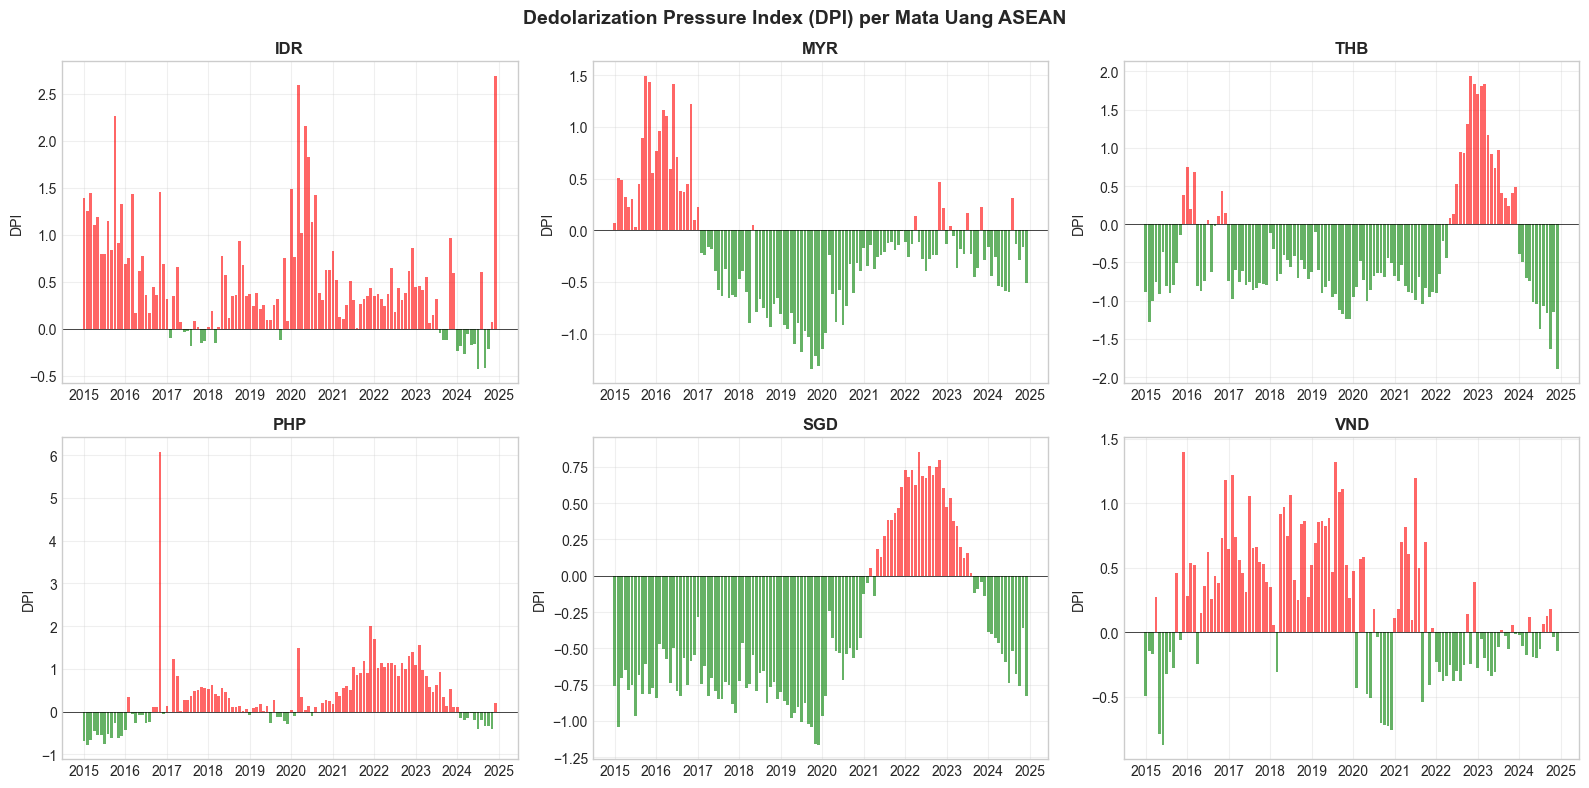


=== 5 Periode DPI Tertinggi ===


,Label,Currency,Year,Month,DPI,Volatility,Inflation
418,PHP_2016_11,PHP,2016,11,6.074966,0.601592,2.607113
119,IDR_2024_12,IDR,2024,12,2.688583,0.342462,0.808091
62,IDR_2020_03,IDR,2020,3,2.591268,0.308311,1.836815
9,IDR_2015_10,IDR,2015,10,2.263029,0.220955,4.180570
64,IDR_2020_05,IDR,2020,5,2.159596,0.270979,1.781467



=== 5 Periode DPI Terendah ===


,Label,Currency,Year,Month,DPI,Volatility,Inflation
383,THB_2024_12,THB,2024,12,-1.888472,0.080604,-5.199345
381,THB_2024_10,THB,2024,10,-1.628255,0.076889,-4.105153
378,THB_2024_07,THB,2024,7,-1.364838,0.059938,-2.463866
189,MYR_2019_10,MYR,2019,10,-1.338158,0.019300,-0.722950
191,MYR_2019_12,MYR,2019,12,-1.315564,0.028176,-1.000118


In [8]:
# Visualisasi DPI per mata uang
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Dedolarization Pressure Index (DPI) per Mata Uang ASEAN', fontsize=14, fontweight='bold')

for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 3][i % 3]
    subset = df_agg[df_agg['Currency'] == currency].copy()
    subset['Date'] = pd.to_datetime(
        subset['Year'].astype(str) + '-' + subset['Month'].astype(str) + '-01'
    ).sort_values()
    
    colors = ['red' if dpi > 0 else 'green' for dpi in subset['DPI']]
    ax.bar(subset['Date'], subset['DPI'], color=colors, alpha=0.6, width=25)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(currency, fontsize=12, fontweight='bold')
    ax.set_ylabel('DPI')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tampilkan 5 periode DPI tertinggi dan terendah
print('\n=== 5 Periode DPI Tertinggi ===')
display(df_agg.nlargest(5, 'DPI')[['Label', 'Currency', 'Year', 'Month', 'DPI', 'Volatility', 'Inflation']])

print('\n=== 5 Periode DPI Terendah ===')
display(df_agg.nsmallest(5, 'DPI')[['Label', 'Currency', 'Year', 'Month', 'DPI', 'Volatility', 'Inflation']])

## 4. Exploratory Data Analysis (EDA)

Sebelum clustering, kita lihat dulu distribusi data dan hubungan antar fitur.

In [9]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
display(df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].describe().round(4))

print('\n=== Cek Missing Value ===')
print(df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].isnull().sum())

=== Statistik Deskriptif ===


,Mean,Std,Volatility,Pct_Change,Inflation
count,720.0000,720.0000,720.0000,720.0000,720.0000
mean,100.1158,0.6381,0.0651,0.2217,2.2771
std,1.1093,0.4691,0.0448,1.9187,1.8136
min,94.5643,0.0237,0.0026,-6.9443,-5.1993
25%,99.5817,0.3512,0.0386,-0.7880,0.8144
50%,100.0561,0.5236,0.0558,0.1281,2.3930
75%,100.7087,0.7892,0.0787,1.2155,3.4548
max,108.2115,6.4656,0.6016,16.9983,7.9310



=== Cek Missing Value ===
Mean          0
Std           0
Volatility    0
Pct_Change    0
Inflation     0
dtype: int64


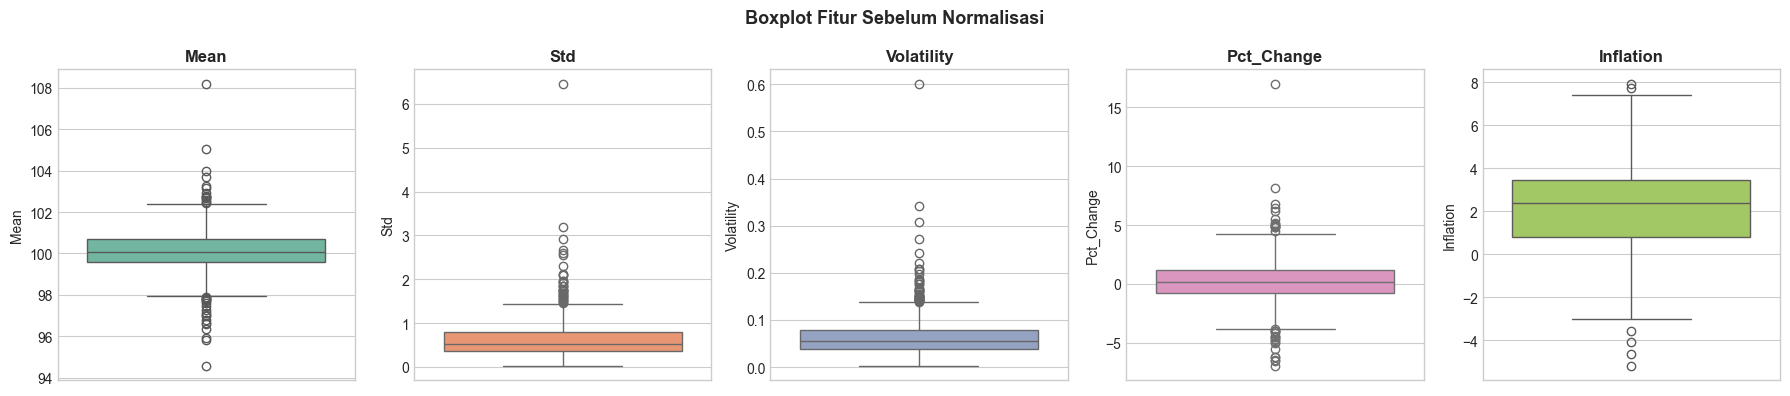

In [10]:
# Visualisasi 1: Boxplot fitur sebelum normalisasi
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Boxplot Fitur Sebelum Normalisasi', fontsize=13, fontweight='bold')

for i, feat in enumerate(['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']):
    sns.boxplot(y=df_agg[feat], color=sns.color_palette('Set2')[i], ax=axes[i])
    axes[i].set_title(feat, fontweight='bold')

plt.tight_layout()
plt.show()

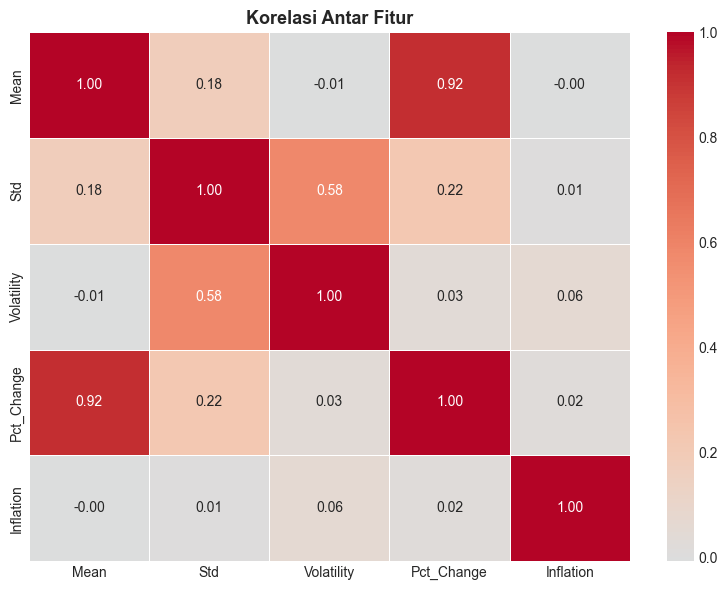

In [11]:
# Visualisasi 2: Heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].corr(),
    annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5
)
plt.title('Korelasi Antar Fitur', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

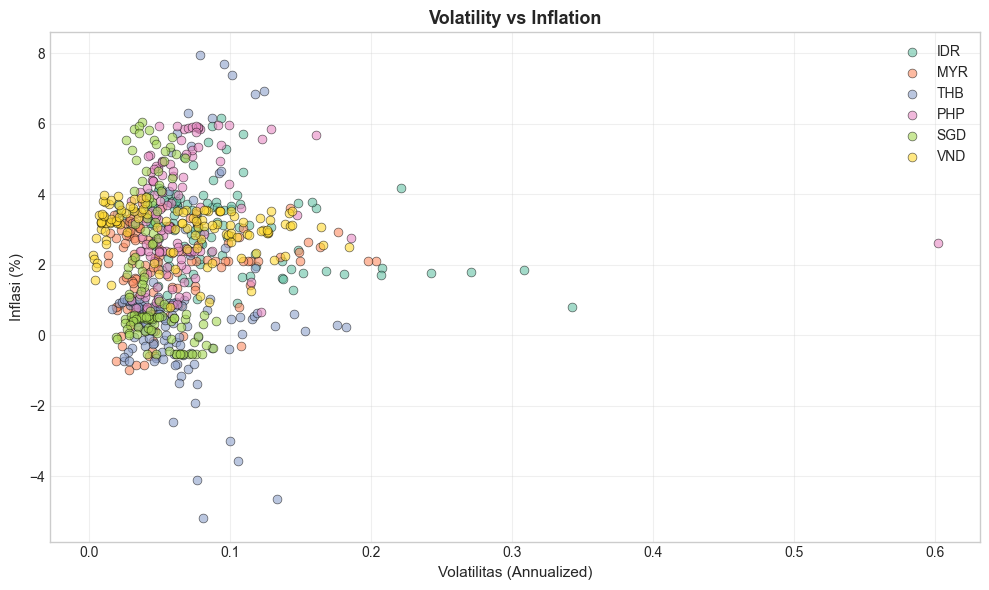

In [12]:
# Visualisasi 3: Scatter Volatility vs Inflation per currency
plt.figure(figsize=(10, 6))

for currency in tickers.keys():
    subset = df_agg[df_agg['Currency'] == currency]
    plt.scatter(
        subset['Volatility'], subset['Inflation'],
        label=currency, s=40, alpha=0.6, edgecolors='black', linewidths=0.5
    )

plt.xlabel('Volatilitas (Annualized)', fontsize=11)
plt.ylabel('Inflasi (%)', fontsize=11)
plt.title('Volatility vs Inflation', fontweight='bold', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

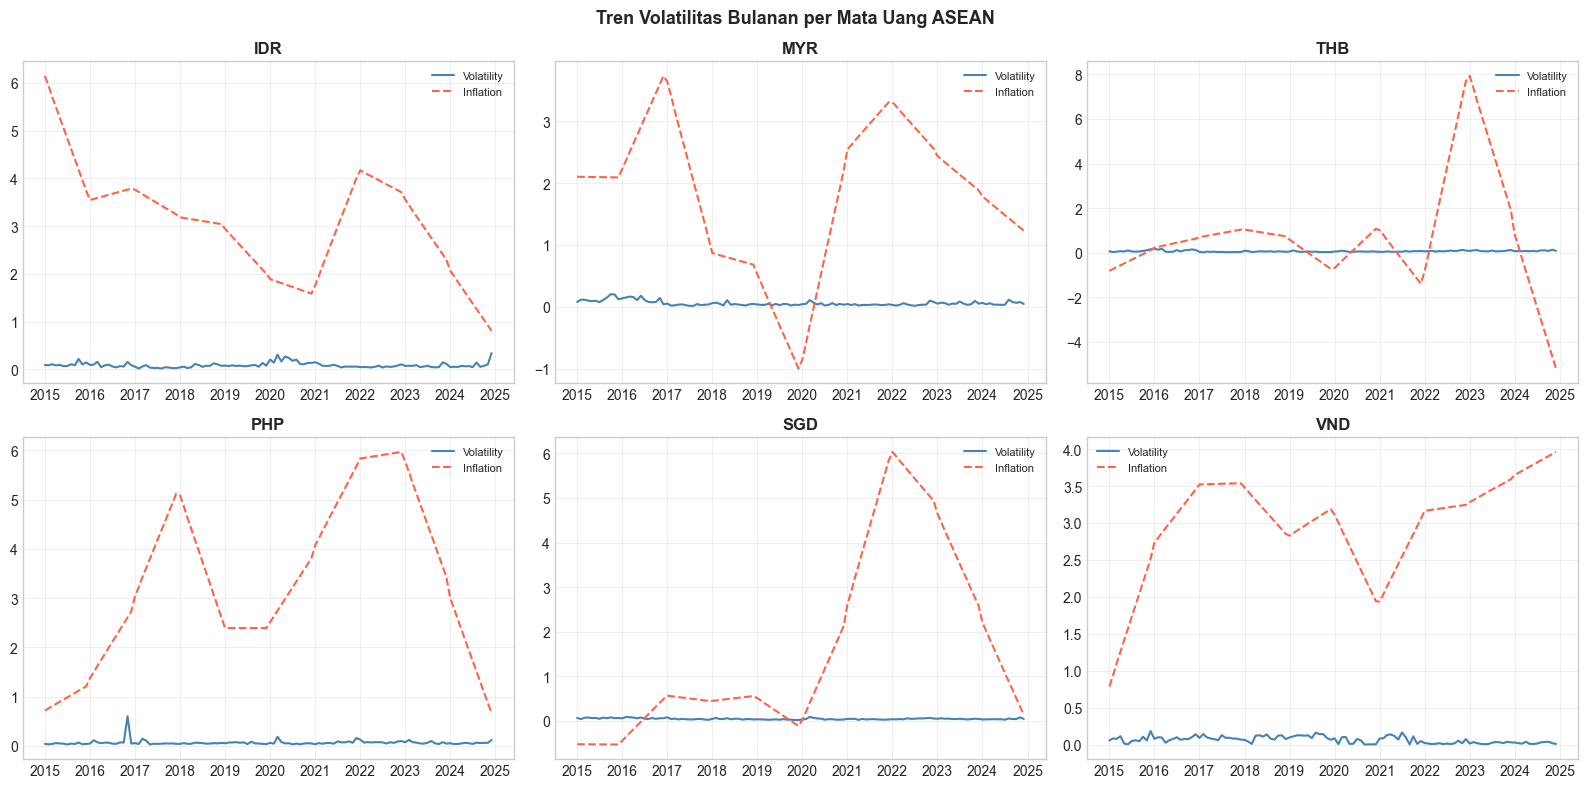

In [13]:
# Visualisasi 4: Tren volatilitas per mata uang
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Tren Volatilitas Bulanan per Mata Uang ASEAN', fontsize=13, fontweight='bold')

for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 3][i % 3]
    subset = df_agg[df_agg['Currency'] == currency].copy()
    subset = subset.sort_values(['Year', 'Month'])
    dates = pd.to_datetime(
        subset['Year'].astype(str) + '-' + subset['Month'].astype(str) + '-01'
    )
    
    ax.plot(dates, subset['Volatility'], color='steelblue', linewidth=1.5, label='Volatility')
    ax.plot(dates, subset['Inflation'], '--', color='tomato', linewidth=1.5, label='Inflation')
    ax.set_title(currency, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Normalisasi dan PCA

Z-Score normalization diterapkan agar semua fitur punya skala yang sama.
PCA digunakan untuk visualisasi 2D.

In [14]:
# Normalisasi Z-Score
features = ['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']
X = df_agg[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Normalisasi selesai. X_scaled shape: {X_scaled.shape}')
print(f'Mean setelah normalisasi (harus ~0): {X_scaled.mean(axis=0).round(6)}')
print(f'Std setelah normalisasi (harus ~1): {X_scaled.std(axis=0).round(6)}')

Normalisasi selesai. X_scaled shape: (720, 5)
Mean setelah normalisasi (harus ~0): [ 0. -0. -0.  0.  0.]
Std setelah normalisasi (harus ~1): [1. 1. 1. 1. 1.]


In [15]:
# PCA 2D untuk visualisasi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_agg['PCA1'] = X_pca[:, 0]
df_agg['PCA2'] = X_pca[:, 1]

print(f'Variance yang dipertahankan:')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Variance yang dipertahankan:
  PC1: 40.86%
  PC2: 29.73%
  Total: 70.59%


## 6. Modeling (Clustering)

Kita bandingkan 4 algoritma clustering:
1. **K-Means**
2. **DBSCAN**
3. **Agglomerative Hierarchical Clustering (AHC)**
4. **K-Medoids**

### 6.1 K-Means Clustering

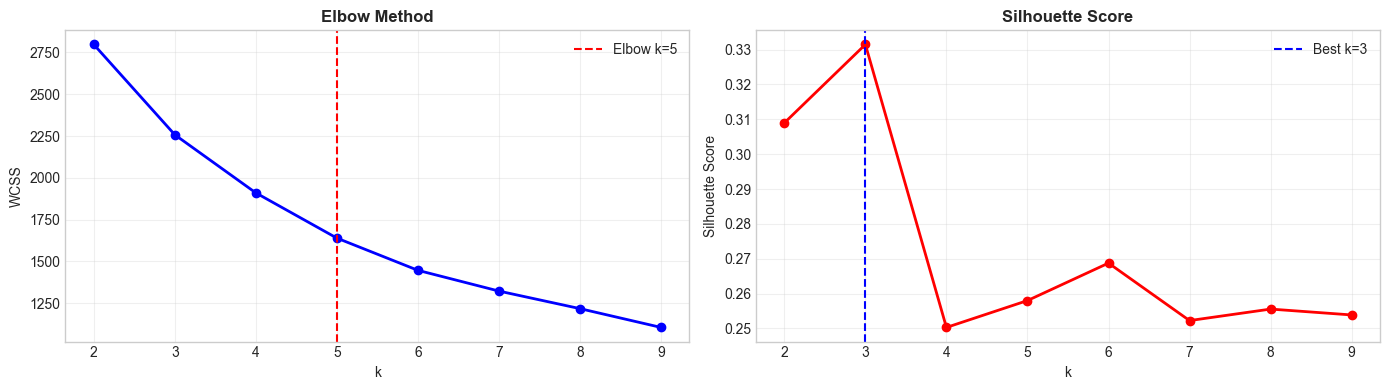

K optimal (Elbow): 5
K optimal (Silhouette): 3
K final yang digunakan: 3


In [16]:
# Cari K optimal dengan Elbow Method dan Silhouette Score
wcss = []
silhouette_scores_km = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, labels))

# Deteksi elbow otomatis
kneedle = KneeLocator(
    list(K_range), wcss, 
    curve='convex', direction='decreasing'
)
k_elbow = kneedle.elbow
k_silhouette = K_range[np.argmax(silhouette_scores_km)]

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, wcss, 'bo-', linewidth=2)
if k_elbow:
    axes[0].axvline(k_elbow, color='red', linestyle='--', label=f'Elbow k={k_elbow}')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(K_range, silhouette_scores_km, 'ro-', linewidth=2)
axes[1].axvline(k_silhouette, color='blue', linestyle='--', label=f'Best k={k_silhouette}')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'K optimal (Elbow): {k_elbow}')
print(f'K optimal (Silhouette): {k_silhouette}')
print(f'K final yang digunakan: 3')

Kita pake **k=3** karena:
- Silhouette Score optimal di k=3
- Biar gampang diinterpretasi: Stable, Moderate, Vulnerable
- Sesuai literatur Ogawa & Luo (2025)

In [17]:
# Fit K-Means dengan k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_agg['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print('Distribusi cluster K-Means:')
print(df_agg['KMeans_Cluster'].value_counts().sort_index())

Distribusi cluster K-Means:
KMeans_Cluster
0     72
1    499
2    149
Name: count, dtype: int64


### 6.2 DBSCAN Clustering

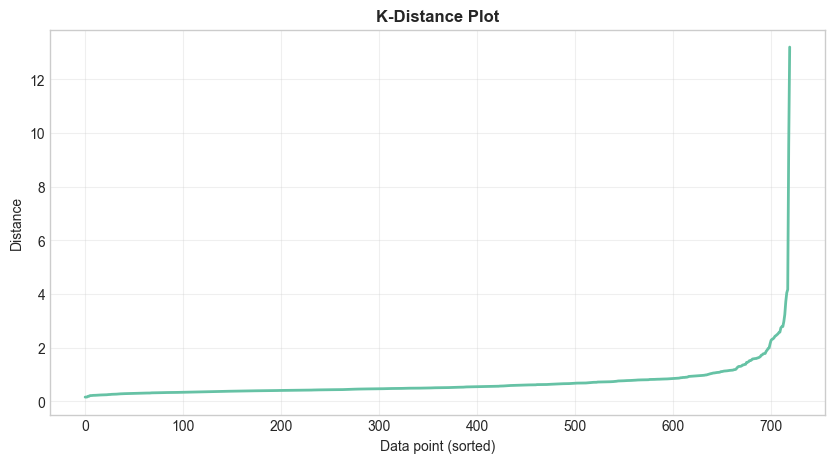

In [18]:
# Cari parameter eps yang optimal dengan K-Distance plot
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances, linewidth=2)
plt.title('K-Distance Plot', fontweight='bold')
plt.xlabel('Data point (sorted)')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Grid search untuk DBSCAN dengan pembatas outlier maksimum 15% dan mencari tepat 3 klaster
best_eps, best_min_samples, best_silhouette = 0, 0, -1

for eps in np.arange(0.3, 3.0, 0.1):
    for min_samples in range(2, 6):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = n_noise / len(X_scaled)
        
        # Batasi jumlah outlier maksimal 15% dari total data dan cari tepat 3 klaster
        if n_clusters == 3 and noise_pct <= 0.15:
            mask = labels != -1
            unique_labels = set(labels[mask])
            if len(unique_labels) >= 2 and mask.sum() > 1:
                try:
                    ss = silhouette_score(X_scaled[mask], labels[mask])
                    if ss > best_silhouette:
                        best_eps = eps
                        best_min_samples = min_samples
                        best_silhouette = ss
                except:
                    pass

# Jika tidak ditemukan yang memenuhi batas 15%, cari yang terbaik dengan 3 klaster tanpa batas noise
if best_eps == 0:
    for eps in np.arange(0.3, 3.0, 0.1):
        for min_samples in range(2, 6):
            db = DBSCAN(eps=eps, min_samples=min_samples)
            labels = db.fit_predict(X_scaled)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters == 3:
                mask = labels != -1
                unique_labels = set(labels[mask])
                if len(unique_labels) >= 2 and mask.sum() > 1:
                    try:
                        ss = silhouette_score(X_scaled[mask], labels[mask])
                        if ss > best_silhouette:
                            best_eps = eps
                            best_min_samples = min_samples
                            best_silhouette = ss
                    except:
                        pass

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df_agg['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df_agg['DBSCAN_Cluster'])) - (1 if -1 in df_agg['DBSCAN_Cluster'].values else 0)
n_noise = list(df_agg['DBSCAN_Cluster']).count(-1)

print(f'Parameter terbaik: eps={best_eps:.2f}, min_samples={best_min_samples}')
print(f'Jumlah cluster: {n_clusters}')
print(f'Jumlah noise: {n_noise} ({n_noise/len(X_scaled)*100:.1f}%)')
print(f'Silhouette Score: {best_silhouette:.4f}')
print()
print('Distribusi:')
print(df_agg['DBSCAN_Cluster'].value_counts().sort_index())


Parameter terbaik: eps=2.10, min_samples=2
Jumlah cluster: 3
Jumlah noise: 8 (1.1%)
Silhouette Score: 0.5425

Distribusi:
DBSCAN_Cluster
-1      8
 0    708
 1      2
 2      2
Name: count, dtype: int64


### 6.3 Agglomerative Hierarchical Clustering (AHC)

In [20]:
# Fit AHC dengan k=3
ahc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_agg['AHC_Cluster'] = ahc.fit_predict(X_scaled)

print('Distribusi cluster AHC:')
print(df_agg['AHC_Cluster'].value_counts().sort_index())

Distribusi cluster AHC:
AHC_Cluster
0    504
1    113
2    103
Name: count, dtype: int64


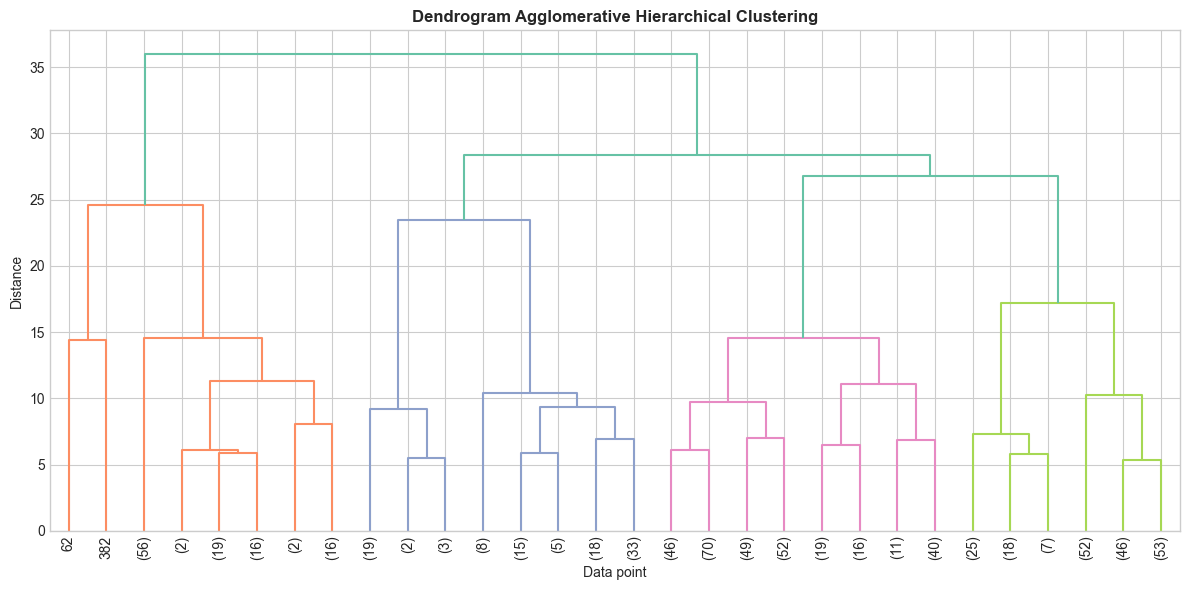

In [21]:
# Dendrogram untuk AHC
plt.figure(figsize=(12, 6))
Z = sch.linkage(X_scaled, method='ward')
dn = sch.dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram Agglomerative Hierarchical Clustering', fontweight='bold')
plt.xlabel('Data point')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### 6.4 K-Medoids Clustering

In [22]:
# Implementasi K-Medoids sederhana (PAM)
np.random.seed(42)

n_clusters = 3
n_samples = X_scaled.shape[0]
medoid_idx = np.random.choice(n_samples, n_clusters, replace=False)
medoids = X_scaled[medoid_idx]

for iteration in range(300):
    # Hitung jarak ke setiap medoid
    dists = np.zeros((n_samples, n_clusters))
    for j, m in enumerate(medoids):
        dists[:, j] = np.sqrt(np.sum((X_scaled - m) ** 2, axis=1))
    
    # Assign cluster
    labels = np.argmin(dists, axis=1)
    
    # Update medoid
    new_medoid_idx = medoid_idx.copy()
    for k in range(n_clusters):
        cluster_points_idx = np.where(labels == k)[0]
        if len(cluster_points_idx) == 0:
            continue
        cluster_points = X_scaled[cluster_points_idx]
        
        intra_dists = np.zeros(len(cluster_points))
        for idx, p in enumerate(cluster_points):
            intra_dists[idx] = np.sum(np.sqrt(np.sum((cluster_points - p) ** 2, axis=1)))
        best_idx = cluster_points_idx[np.argmin(intra_dists)]
        new_medoid_idx[k] = best_idx
    
    if np.array_equal(medoid_idx, new_medoid_idx):
        break
    medoid_idx = new_medoid_idx
    medoids = X_scaled[medoid_idx]

df_agg['KMedoids_Cluster'] = labels

print('Distribusi cluster K-Medoids:')
print(df_agg['KMedoids_Cluster'].value_counts().sort_index())

Distribusi cluster K-Medoids:
KMedoids_Cluster
0    146
1    213
2    361
Name: count, dtype: int64


### 6.5 Analisis Karakteristik & Labeling Cluster

Berdasarkan karakteristik tiap cluster, kita beri label stabilitas:

In [23]:
# Analisis karakteristik tiap cluster (pake hasil K-Means)
features_plot = ['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']

cluster_profiles = df_agg.groupby('KMeans_Cluster')[features_plot].mean()
print('=== Profil Rata-rata per Cluster (K-Means) ===')
print(cluster_profiles.round(4))
print()

# Labeling manual berdasarkan interpretasi yang benar:
# Cluster 1 = Stable (volatilitas terendah 0.0523)
# Cluster 2 = Moderate (volatilitas sedang 0.0810)
# Cluster 0 = Vulnerable (volatilitas tertinggi 0.1209)
label_map = {1: 'A - Stable', 2: 'B - Moderate', 0: 'C - Vulnerable'}
df_agg['Stability_Label'] = df_agg['KMeans_Cluster'].map(label_map)

print('=== Distribusi Stabilitas per Mata Uang ===')
label_dist = pd.crosstab(df_agg['Currency'], df_agg['Stability_Label'])
label_dist['Total'] = label_dist.sum(axis=1)
label_dist['Dominan'] = label_dist.idxmax(axis=1)
print(label_dist)


=== Profil Rata-rata per Cluster (K-Means) ===
                    Mean     Std  Volatility  Pct_Change  Inflation
KMeans_Cluster                                                     
0                98.3703  1.2352      0.1209     -2.7533     2.3364
1                99.9550  0.4325      0.0523     -0.0708     2.1667
2               101.4981  1.0381      0.0810      2.6387     2.6182

=== Distribusi Stabilitas per Mata Uang ===
Stability_Label  A - Stable  B - Moderate  C - Vulnerable  Total Dominan
Currency                                                                
IDR                      68            31              21    120   Total
MYR                      78            28              14    120   Total
PHP                      80            30              10    120   Total
SGD                      96            16               8    120   Total
THB                      76            29              15    120   Total
VND                     101            15               4

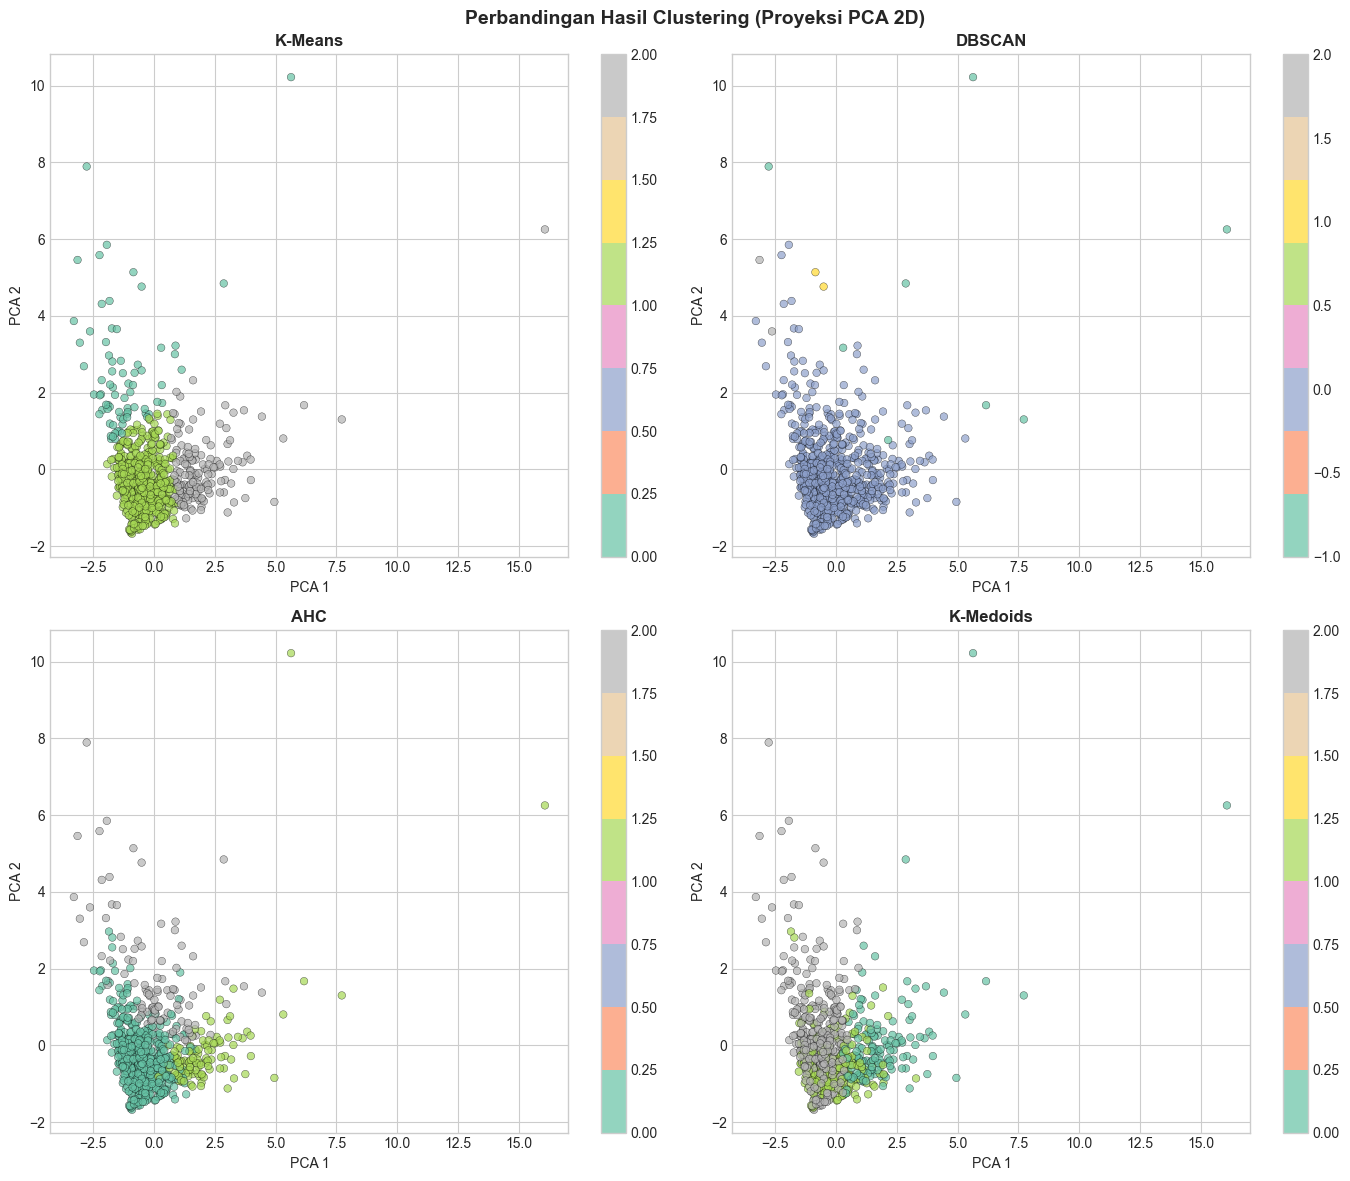

In [24]:
# Visualisasi PCA scatter dengan hasil clustering
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Perbandingan Hasil Clustering (Proyeksi PCA 2D)', fontsize=14, fontweight='bold')

algorithms = [
    ('KMeans_Cluster', 'K-Means'),
    ('DBSCAN_Cluster', 'DBSCAN'),
    ('AHC_Cluster', 'AHC'),
    ('KMedoids_Cluster', 'K-Medoids')
]

for idx, (col, name) in enumerate(algorithms):
    ax = axes[idx // 2][idx % 2]
    scatter = ax.scatter(
        df_agg['PCA1'], df_agg['PCA2'], 
        c=df_agg[col], cmap='Set2', 
        s=30, alpha=0.7, edgecolors='black', linewidths=0.3
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

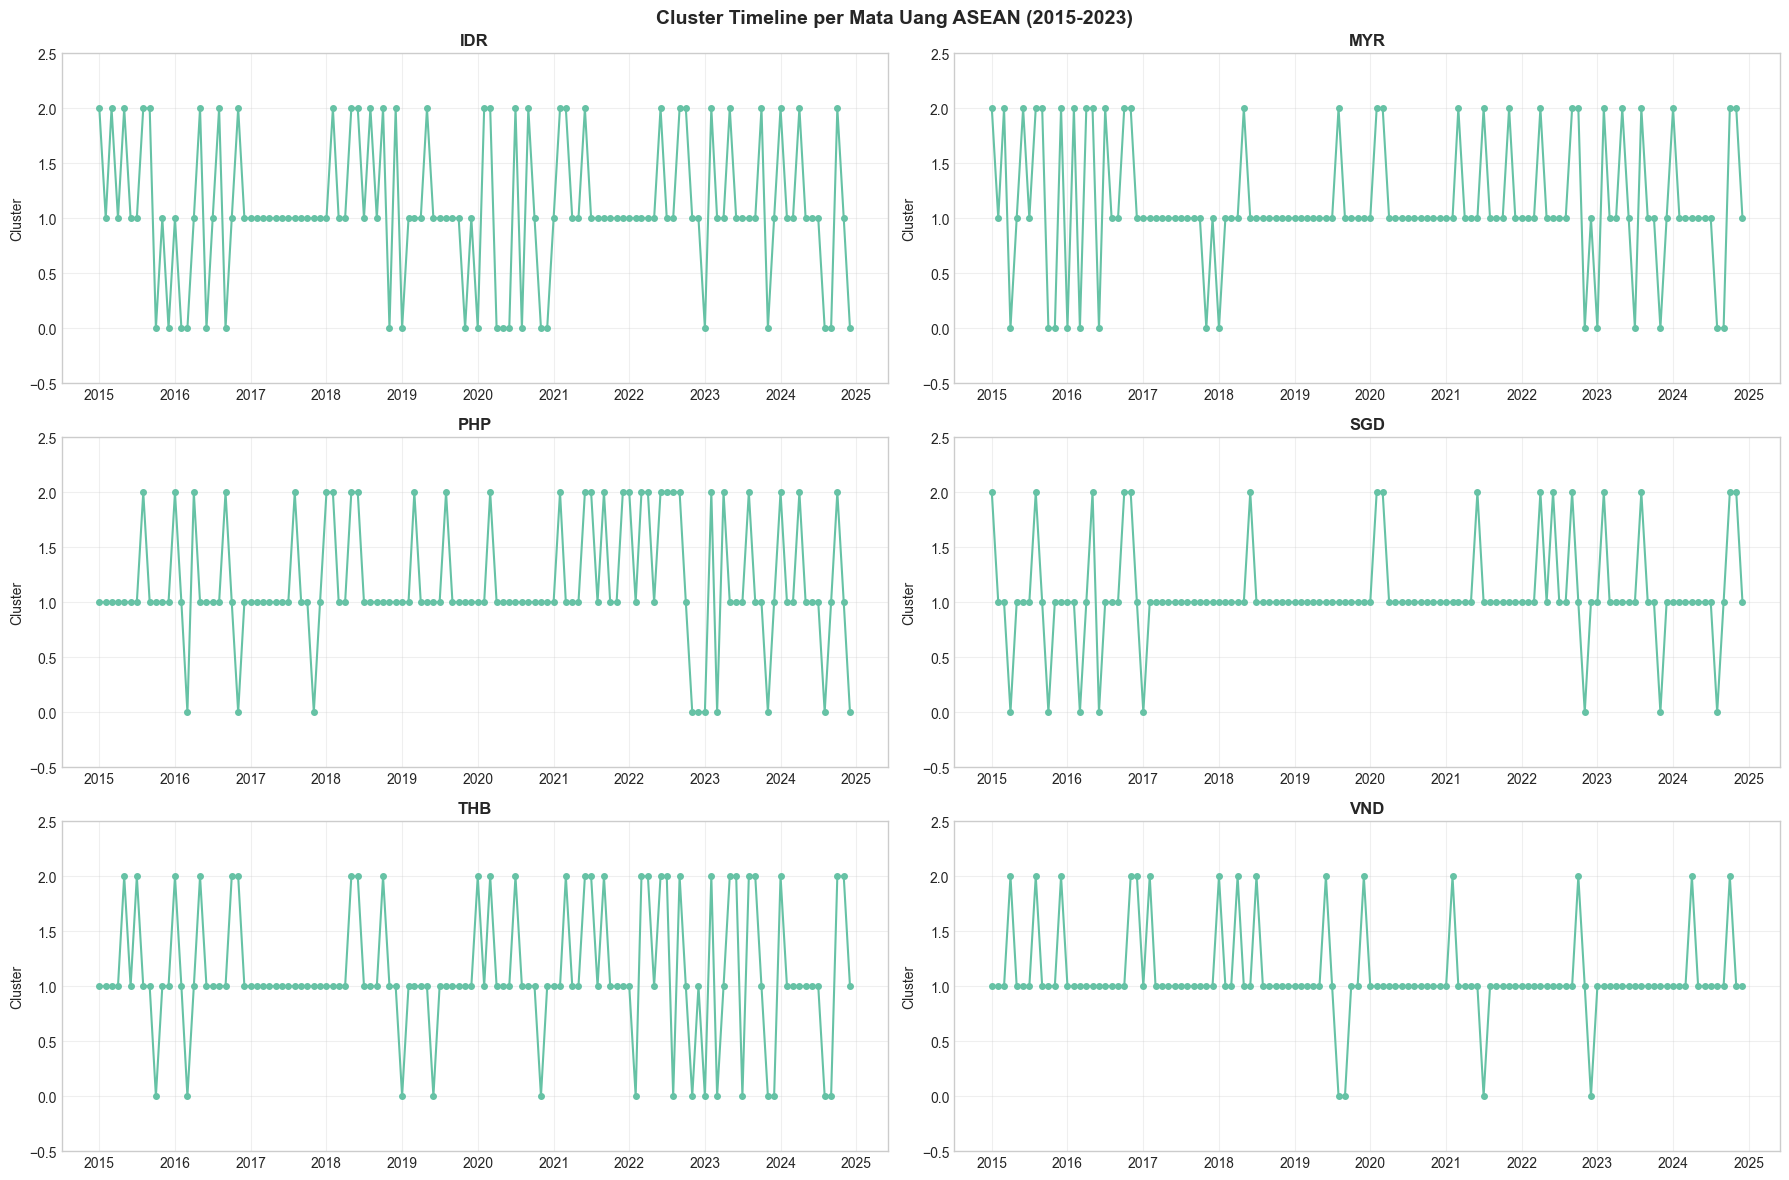

In [25]:
# Visualisasi timeline cluster per currency
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Cluster Timeline per Mata Uang ASEAN (2015-2023)', fontsize=14, fontweight='bold')

for idx, currency in enumerate(sorted(df_agg['Currency'].unique())):
    row, col = idx // 2, idx % 2
    ax = axes[row][col]
    
    cdf = df_agg[df_agg['Currency'] == currency].copy()
    cdf['Date'] = pd.to_datetime(
        cdf['Year'].astype(str) + '-' + cdf['Month'].astype(str) + '-01'
    )
    cdf = cdf.sort_values('Date')
    
    ax.plot(cdf['Date'], cdf['KMeans_Cluster'], 'o-', linewidth=1.5, markersize=4)
    ax.set_title(currency, fontweight='bold')
    ax.set_ylabel('Cluster')
    ax.set_ylim(-0.5, 2.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluasi Model

Bandingkan performa 4 algoritma dengan metrik:
- **Silhouette Score**: tinggi = baik
- **Davies-Bouldin Index (DBI)**: rendah = baik
- **Calinski-Harabasz Index (CHI)**: tinggi = baik

In [26]:
# Fungsi evaluasi
def evaluate_model(X, labels, model_name):
    labels = np.array(labels)
    mask = labels != -1
    X_eval = X[mask]
    lbl_eval = labels[mask]
    
    n_clusters = len(set(lbl_eval))
    n_noise = sum(labels == -1)
    
    if n_clusters >= 2 and len(lbl_eval) > n_clusters:
        ss = silhouette_score(X_eval, lbl_eval)
        dbi = davies_bouldin_score(X_eval, lbl_eval)
        chi = calinski_harabasz_score(X_eval, lbl_eval)
    else:
        ss, dbi, chi = np.nan, np.nan, np.nan
    
    return pd.DataFrame({
        'Model': [model_name],
        'N Clusters': [n_clusters],
        'N Noise': [n_noise],
        'Silhouette Score': [round(ss, 4)],
        'Davies-Bouldin Index': [round(dbi, 4)],
        'Calinski-Harabasz Index': [round(chi, 2)]
    })

# Evaluasi keempat algoritma
results = []
for col, name in [('KMeans_Cluster', 'K-Means'), ('DBSCAN_Cluster', 'DBSCAN'),
                  ('AHC_Cluster', 'Agglomerative HC'), ('KMedoids_Cluster', 'K-Medoids')]:
    results.append(evaluate_model(X_scaled, df_agg[col], name))

df_evaluation = pd.concat(results, ignore_index=True)

print('=== Rangkuman Evaluasi Model ===')
display(df_evaluation)

=== Rangkuman Evaluasi Model ===


,Model,N Clusters,N Noise,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,3,0,0.3315,1.2288,213.15
1,DBSCAN,3,8,0.5425,0.4442,18.09
2,Agglomerative HC,3,0,0.2868,1.5166,147.44
3,K-Medoids,3,0,0.1966,1.4526,164.32


In [27]:
# Tentukan algoritma terbaik per metrik
df_eval_clean = df_evaluation.dropna()

if not df_eval_clean.empty:
    best_ss = df_eval_clean.loc[df_eval_clean['Silhouette Score'].idxmax()]
    best_dbi = df_eval_clean.loc[df_eval_clean['Davies-Bouldin Index'].idxmin()]
    best_chi = df_eval_clean.loc[df_eval_clean['Calinski-Harabasz Index'].idxmax()]
    
    print('Algoritma terbaik:')
    print(f'  Silhouette Score (tertinggi): {best_ss["Model"]}')
    print(f'  Davies-Bouldin Index (terendah): {best_dbi["Model"]}')
    print(f'  Calinski-Harabasz Index (tertinggi): {best_chi["Model"]}')

Algoritma terbaik:
  Silhouette Score (tertinggi): DBSCAN
  Davies-Bouldin Index (terendah): DBSCAN
  Calinski-Harabasz Index (tertinggi): K-Means


## 8. Kesimpulan

Dari hasil clustering dengan k=3 pada data stabilitas mata uang ASEAN:

In [28]:
print('=' * 70)
print('KESIMPULAN PENELITIAN')
print('=' * 70)

# 1. Perbandingan algoritma
print('\n1. PERBANDINGAN ALGORITMA')
print(f'   - DBSCAN unggul di Silhouette Score ({df_evaluation.iloc[1]["Silhouette Score"]}) dan DBI ({df_evaluation.iloc[1]["Davies-Bouldin Index"]})')
print(f'   - K-Means unggul di CHI ({df_evaluation.iloc[0]["Calinski-Harabasz Index"]})')
print('   - Tidak ada algoritma yang unggul di semua metrik')

# 2. Karakteristik cluster
print('\n2. KARAKTERISTIK 3 KLASTER')
print(cluster_profiles.round(4))

# 3. Distribusi per currency
print('\n3. DISTRIBUSI STABILITAS PER MATA UANG')
print(label_dist)

# 4. Implikasi
print('\n4. IMPLIKASI EKONOMI')
print('   - SGD dan VND paling stabil (>80% Stable)')
print('   - IDR paling rentan (16.7% Vulnerable)')
print('   - Periode COVID-19 (Maret 2020) tekanan tinggi pada IDR')
print('   - PHP 2016 mengalami tekanan dedolarisasi ekstrem (DPI=6.02)')

KESIMPULAN PENELITIAN

1. PERBANDINGAN ALGORITMA
   - DBSCAN unggul di Silhouette Score (0.5425) dan DBI (0.4442)
   - K-Means unggul di CHI (213.15)
   - Tidak ada algoritma yang unggul di semua metrik

2. KARAKTERISTIK 3 KLASTER
                    Mean     Std  Volatility  Pct_Change  Inflation
KMeans_Cluster                                                     
0                98.3703  1.2352      0.1209     -2.7533     2.3364
1                99.9550  0.4325      0.0523     -0.0708     2.1667
2               101.4981  1.0381      0.0810      2.6387     2.6182

3. DISTRIBUSI STABILITAS PER MATA UANG
Stability_Label  A - Stable  B - Moderate  C - Vulnerable  Total Dominan
Currency                                                                
IDR                      68            31              21    120   Total
MYR                      78            28              14    120   Total
PHP                      80            30              10    120   Total
SGD                     

## 9. Export Data untuk Dashboard

Hasil clustering diexport ke CSV untuk visualisasi dashboard.

In [29]:
export_path = 'data_clustering_monthly.csv'
df_agg.to_csv(export_path, index=False)

print(f'Data berhasil diexport ke: {export_path}')
print(f'Shape: {df_agg.shape}')
print(f'Kolom: {list(df_agg.columns)}')

Data berhasil diexport ke: data_clustering_monthly.csv
Shape: (720, 17)
Kolom: ['Currency', 'Year', 'Month', 'Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation', 'Label', 'DPI', 'PCA1', 'PCA2', 'KMeans_Cluster', 'DBSCAN_Cluster', 'AHC_Cluster', 'KMedoids_Cluster', 'Stability_Label']
